# Informatyka w medycynie: Projekt 1 - Tomograf

Instalowanie paczek (odkomentować jeśli nie zainstalowano)

In [85]:
# %pip install Pillow matplotlib numpy scipy scikit-image

In [86]:
import os
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import math
from sklearn.metrics import mean_squared_error
from skimage import draw
import sys
from skimage.draw import line as skimage_line

## 1. Sinogram

### Wczytanie pliku

In [87]:
# path = "tomograf-obrazy/Kolo.jpg"
path = "tomograf-obrazy/Paski2.jpg"

if os.path.exists(path):
    image_pil = Image.open(path).convert("L") # Konwersja do skali szarości
    image = np.array(image_pil)
else:
    print(f"Nie można znaleźć pliku {path}")

### Prześwietlanie obrazu

In [88]:
def read_line(image, r0, c0, r1, c1):
    rr, cc = draw.line(r0, c0, r1, c1)
    line_values = []
    for r, c in zip(rr, cc):
        if 0 <= r < image.shape[0] and 0 <= c < image.shape[1]:
            line_values.append(image[r, c])
        else:
            line_values.append(0)  # Dodaj 0, jeśli punkt jest poza obrazem
    return line_values

line_values = read_line(image, 0, 0, image.shape[1]-1, image.shape[0]-1)
print(line_values)

[np.uint8(0), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(254), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(255), np.uint8(25

In [89]:
print(f"data type: {image.dtype}")  # uint8 => standard dla bitmapy
print(f"width x hight: {image.shape}") # dowód prostokątności
print(f"number of canals: {len(image.shape)}") # 2 oznacza brak kolorów (czystą skalę szarości)

data type: uint8
width x hight: (400, 400)
number of canals: 2


TWORZENIE DETEKTORÓW I EMITRÓ DLA KĄTA I

In [90]:
def set_positions_parallel(rotation_angle, detector_count, spread, center_x, center_y):
    # Calculates start and end points at a given rotation angle.
    

    # Rotation angle to radians
    alpha_rad = np.deg2rad(rotation_angle)
    
    # Direction vectors for the main axis (cos and sin)
    cos_a = np.cos(alpha_rad)
    sin_a = np.sin(alpha_rad)
    
    start_points = [] # where rays start
    end_points = []   # where rays end

    # Minimum radius needed to cover the entire rectangular image during 360 rotation. 
    radius = np.sqrt(center_x**2 + center_y**2) + 10 
    
    # Position emitters and detectors in a straight line
    for i in range(detector_count):
        # Offset of every ray sideways from the center
        offset = (i * (spread / (detector_count - 1 if detector_count > 1 else 1))) - (spread / 2)
        
        # set start point (Emitter i)
        xs = center_x + radius * cos_a + offset * (-sin_a)
        ys = center_y + radius * sin_a + offset * (cos_a)
        
        # set end point (Detector i)
        xe = center_x - radius * cos_a + offset * (-sin_a)
        ye = center_y - radius * sin_a + offset * (cos_a)
        
        start_points.append((xs, ys))
        end_points.append((xe, ye))
        
    return start_points, end_points

starts, ends = set_positions_parallel(0, 3, 500, image.shape[1]//2, image.shape[0]//2)
print(starts)
print(ends)

[(np.float64(492.842712474619), np.float64(-50.0)), (np.float64(492.842712474619), np.float64(200.0)), (np.float64(492.842712474619), np.float64(450.0))]
[(np.float64(-92.84271247461902), np.float64(-50.0)), (np.float64(-92.84271247461902), np.float64(200.0)), (np.float64(-92.84271247461902), np.float64(450.0))]


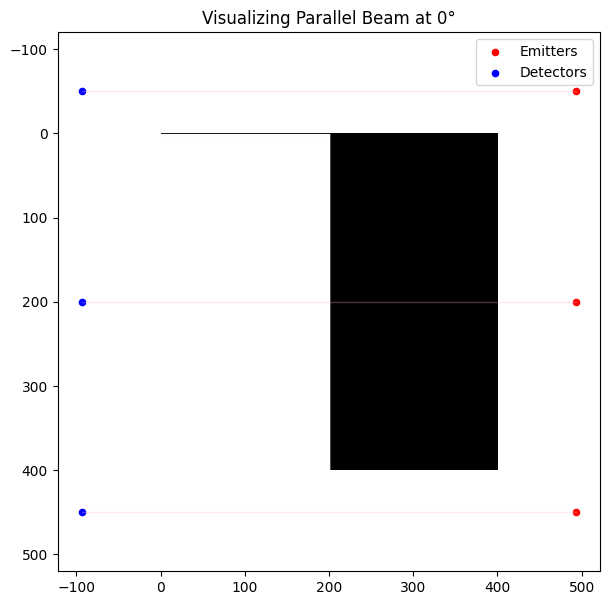

In [91]:
import matplotlib.pyplot as plt

def plot_scanner_visualization(image, starts, ends, angle):
    # Pobieramy wymiary bezpośrednio z Twojego obrazka
    height, width = image.shape
    
    plt.figure(figsize=(7, 7))
    ax = plt.gca()
    
    # 1. Rysujemy Twój obrazek w tle (skala szarości)
    plt.imshow(image, cmap='gray', extent=[0, width, height, 0])
    
    # 2. Rysujemy linie strzału (cienkie, szare)
    for s, e in zip(starts, ends):
        plt.plot([s[0], e[0]], [s[1], e[1]], color='pink', alpha=0.3, linewidth=1)
    
    # 3. Zaznaczamy punkty
    starts_x, starts_y = zip(*starts)
    ends_x, ends_y = zip(*ends)
    plt.scatter(starts_x, starts_y, color='red', s=20, label='Emitters')
    plt.scatter(ends_x, ends_y, color='blue', s=20, label='Detectors')
    
    plt.title(f"Visualizing Parallel Beam at {angle}°")
    plt.legend()
    plt.axis('equal')
    plt.show()

plot_scanner_visualization(image, starts, ends, 0)


---

to tworzenia linii pomiędzy emiterami i detektorami

In [92]:
def bresenham(x0, y0, x1, y1):
    return skimage_line(int(x0), int(y0), int(x1), int(y1))

Tworzymy sinogram

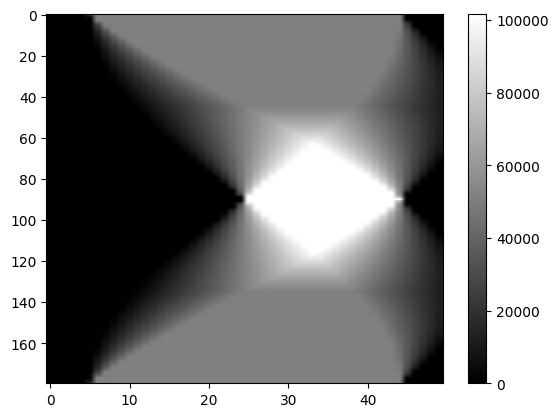

In [93]:
def create_sinogram(image, num_steps, num_detectors, spread):
    # tablica na wyniki
    # Wiersze = kąty obrotu, Kolumny = detektory
    sinogram = np.zeros((num_steps, num_detectors))
    
    # środek obrazu
    c_x, c_y = image.shape[1] // 2, image.shape[0] // 2
    
    # przez kąty
    for step in range(num_steps):
        angle = step * (180.0 / num_steps) # wyliczamy konkretny kąt
        
        # pobieramy pozycje emiterów i detektorów
        starts, ends = set_positions_parallel(angle, num_detectors, spread, c_x, c_y)
        
        # Pętla przez każdą parę emiter-detektor
        for i in range(num_detectors):
            
            # lista wartości pikseli na linii
            line_values = read_line(image, int(starts[i][1]), int(starts[i][0]), int(ends[i][1]), int(ends[i][0]))
            
            # Sumujemy jasność pikseli na tej linii
            line_sum = np.sum(line_values, dtype=np.float64)
            
            # Zapisujemy sumę do naszej tablicy
            sinogram[step, i] = line_sum
            
    return sinogram


my_sinogram = create_sinogram(image, 180, 50, 500)
plt.imshow(my_sinogram, cmap='gray', aspect='auto')
plt.colorbar() # Pokaże skalę wartości obok
plt.show()
